In [1]:
library(tidyverse)

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.2 ──
✔ ggplot2 3.4.4     ✔ purrr   1.0.2
✔ tibble  3.2.1     ✔ dplyr   1.1.3
✔ tidyr   1.3.0     ✔ stringr 1.5.0
✔ readr   2.1.4     ✔ forcats 1.0.0
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


In [2]:
library(data.table)


Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The following object is masked from ‘package:purrr’:

    transpose




In [3]:
library(qqman)



For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





In [1]:
one_kg <- read.table("/u/home/a/afcarrol/project-pasaniuc/Projects/20240117_hg19_rsids/snpinfo_mult_1kg_hm3",header = T)
# snp info from https://github.com/getian107/PRScsx - 1kg reference

In [31]:
head(one_kg)

,CHR,SNP,BP,A1,A2,FRQ_AFR,FRQ_AMR,FRQ_EAS,FRQ_EUR,FRQ_SAS,FLP_AFR,FLP_AMR,FLP_EAS,FLP_EUR,FLP_SAS
,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>
1,1,rs2185539,566875,T,C,0.12480,0.00000,0.0000,0.00000,0.0000,1,0,0,0,0
2,1,rs6681105,592075,C,T,0.02194,0.00000,0.0000,0.00000,0.0000,1,0,0,0,0
3,1,rs3131972,752721,A,G,0.70950,0.26370,0.2341,0.16100,0.2219,-1,1,1,1,1
4,1,rs3131969,754182,A,G,0.64750,0.24350,0.2669,0.12820,0.1912,-1,1,1,1,1
5,1,rs1048488,760912,C,T,0.55520,0.19450,0.1161,0.16000,0.1892,-1,1,1,1,1
6,1,rs12562034,768448,A,G,0.08548,0.08934,0.3958,0.09245,0.3006,1,1,1,1,1


In [10]:
one_kg$chrid <- paste(one_kg$CHR, one_kg$BP, one_kg$A2, one_kg$A1, sep=":")

In [33]:
head(one_kg)

,CHR,SNP,BP,A1,A2,FRQ_AFR,FRQ_AMR,FRQ_EAS,FRQ_EUR,FRQ_SAS,FLP_AFR,FLP_AMR,FLP_EAS,FLP_EUR,FLP_SAS,chrid
,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<chr>
1,1,rs2185539,566875,T,C,0.12480,0.00000,0.0000,0.00000,0.0000,1,0,0,0,0,1:566875:C:T
2,1,rs6681105,592075,C,T,0.02194,0.00000,0.0000,0.00000,0.0000,1,0,0,0,0,1:592075:T:C
3,1,rs3131972,752721,A,G,0.70950,0.26370,0.2341,0.16100,0.2219,-1,1,1,1,1,1:752721:G:A
4,1,rs3131969,754182,A,G,0.64750,0.24350,0.2669,0.12820,0.1912,-1,1,1,1,1,1:754182:G:A
5,1,rs1048488,760912,C,T,0.55520,0.19450,0.1161,0.16000,0.1892,-1,1,1,1,1,1:760912:T:C
6,1,rs12562034,768448,A,G,0.08548,0.08934,0.3958,0.09245,0.3006,1,1,1,1,1,1:768448:G:A


In [34]:
table(table(one_kg$SNP))


      1 
1297431 

In [7]:
table(table(one_kg$BP))


      1       2       3 
1288871    4268       8 

ERROR: Error in system2(command, stdout = TRUE, stderr = TRUE): error in running command


In [11]:
gwas_results <- read.csv("/u/project/pasaniuc/afcarrol/Projects/20231219_SPARK_AFR_ASD_GWAS/hg19_hg38_ADD_1-22_spark_afr_asd.csv", header = T)

In [13]:
head(gwas_results)

,CHROM,POS,ID,REF,ALT,A1,TEST,OBS_CT,OR,LOG.OR._SE,Z_STAT,P,hg19
,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
1,1,856473,chr1:856473:G:A,G,A,A,ADD,534,2.235080,1.207670,0.6659740,0.505428,791853
2,1,858952,chr1:858952:G:A,G,A,A,ADD,2087,0.995816,0.241259,-0.0173771,0.986136,794332
3,1,859842,chr1:859842:C:G,C,G,G,ADD,2087,1.471630,0.352725,1.0954000,0.273343,795222
4,1,863421,chr1:863421:G:A,G,A,A,ADD,2087,1.402910,0.350893,0.9648100,0.334640,798801
5,1,864119,chr1:864119:T:C,T,C,C,ADD,2087,1.397430,0.350321,0.9552130,0.339470,799499
6,1,866281,chr1:866281:C:T,C,T,T,ADD,2087,1.314600,0.359768,0.7602930,0.447079,801661


In [12]:
gwas_results <- gwas_results[,c("CHROM", "hg19", "A1", "REF", "OR", "P")] 
colnames(gwas_results) <- c("CHROM", "POS", "A1", "A2", "OR", "P")

In [39]:
head(gwas_results)

,CHROM,POS,A1,A2,OR,P
,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>
1,1,791853,A,G,2.235080,0.505428
2,1,794332,A,G,0.995816,0.986136
3,1,795222,G,C,1.471630,0.273343
4,1,798801,A,G,1.402910,0.334640
5,1,799499,C,T,1.397430,0.339470
6,1,801661,T,C,1.314600,0.447079


In [13]:
gwas_results$chrid <- paste(gwas_results$CHR, gwas_results$POS, gwas_results$A2, gwas_results$A1, sep=":")

In [42]:
head(gwas_results)

,CHROM,POS,A1,A2,OR,P,chrid
,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,1,791853,A,G,2.235080,0.505428,1:791853:G:A
2,1,794332,A,G,0.995816,0.986136,1:794332:G:A
3,1,795222,G,C,1.471630,0.273343,1:795222:C:G
4,1,798801,A,G,1.402910,0.334640,1:798801:G:A
5,1,799499,C,T,1.397430,0.339470,1:799499:T:C
6,1,801661,T,C,1.314600,0.447079,1:801661:C:T


In [14]:
gwas_results <- left_join(gwas_results,one_kg[,c("SNP", "chrid")], by = "chrid" )

In [44]:
head(gwas_results)

,CHROM,POS,A1,A2,OR,P,chrid,SNP
,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
1,1,791853,A,G,2.235080,0.505428,1:791853:G:A,NA
2,1,794332,A,G,0.995816,0.986136,1:794332:G:A,NA
3,1,795222,G,C,1.471630,0.273343,1:795222:C:G,NA
4,1,798801,A,G,1.402910,0.334640,1:798801:G:A,NA
5,1,799499,C,T,1.397430,0.339470,1:799499:T:C,NA
6,1,801661,T,C,1.314600,0.447079,1:801661:C:T,NA


In [39]:
dim(gwas_results)

[1] 8104394       8

In [59]:
sum(!is.na(gwas_results$SNP))

[1] 777771

In [49]:
sum(is.na(gwas_results$SNP))

[1] 7326623

In [32]:
dim(one_kg)

[1] 1297431      16

In [47]:
table(table(gwas_results$POS))


      1       2       3       4       5    9371 
7755679  165894    2477      30       1       1 

In [13]:
gwas_final <- gwas_results[!is.na(gwas_results$SNP),]

In [10]:
dim(gwas_final)

[1] 777771      8

In [14]:
head(gwas_final)

,CHROM,POS,A1,A2,OR,P,chrid,SNP
,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
26,1,846808,T,C,1.115290,0.502999,1:846808:C:T,rs4475691
52,1,854250,G,A,0.852690,0.362257,1:854250:A:G,rs7537756
135,1,918384,T,G,0.862765,0.436854,1:918384:G:T,rs13303118
175,1,932457,A,G,0.867662,0.582309,1:932457:G:A,rs1891910
207,1,944564,C,T,0.962208,0.824258,1:944564:T:C,rs3128117
213,1,947778,G,A,1.457270,0.439091,1:947778:A:G,rs9697358


In [14]:
gwas_final <- gwas_final[,c("SNP", "A1", "A2", "OR", "P")]

In [15]:
head(gwas_final)

,SNP,A1,A2,OR,P
,<chr>,<chr>,<chr>,<dbl>,<dbl>
26,rs4475691,T,C,1.115290,0.502999
52,rs7537756,G,A,0.852690,0.362257
135,rs13303118,T,G,0.862765,0.436854
175,rs1891910,A,G,0.867662,0.582309
207,rs3128117,C,T,0.962208,0.824258
213,rs9697358,G,A,1.457270,0.439091


In [16]:
dim(gwas_final)

[1] 777771      5

In [4]:
write.csv(gwas_final,"saug_1kg_hg19.csv")

ERROR: Error in is.data.frame(x): object 'gwas_final' not found


In [5]:
gwas_final <- read_csv("saug_1kg_hg19.csv")

New names:
• `` -> `...1`
Rows: 777771 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): SNP, A1, A2
dbl (3): ...1, OR, P

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
head(gwas_final)

...1,SNP,A1,A2,OR,P
<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>
26,rs4475691,T,C,1.115290,0.502999
52,rs7537756,G,A,0.852690,0.362257
135,rs13303118,T,G,0.862765,0.436854
175,rs1891910,A,G,0.867662,0.582309
207,rs3128117,C,T,0.962208,0.824258
213,rs9697358,G,A,1.457270,0.439091


In [8]:
man_plot <- manhattan(gwas_final[!is.na(gwas_final$SNP),], 
          chr = "CHROM", 
          bp = "POS", 
          snp = "SNP", 
          p = "P", 
          col = c("black", "grey"), 
          main = "SPARK AFR ASD Unrelated")

ERROR: Error in manhattan(gwas_final[!is.na(gwas_final$SNP), ], chr = "CHROM", : Column CHROM not found!


In [17]:
write.table(gwas_final, 
            file = "saug_1kg_hg19.txt", 
            sep = "\t", quote = FALSE, row.names = FALSE, col.names = TRUE)

In [29]:
gwas_final <- read.table(file = "saug_1kg_hg19.txt", col.names = TRUE)

ERROR: Error in read.table(file = "saug_1kg_hg19.txt", col.names = TRUE): more columns than column names


In [28]:
head(gwas_final)

,V1,V2,V3,V4,V5,V6,V7,V8
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,CHROM,POS,A1,A2,OR,P,chrid,SNP
2,NA,NA,NA,NA,NA,NA,NA,NA
3,NA,NA,NA,NA,NA,NA,NA,NA
4,NA,NA,NA,NA,NA,NA,NA,NA
5,NA,NA,NA,NA,NA,NA,NA,NA
6,NA,NA,NA,NA,NA,NA,NA,NA


In [ ]:
# /u/project/pasaniuc/pasaniucdata/DATA/LDSC/1000G_EUR/1000G_EUR_Phase3_plink

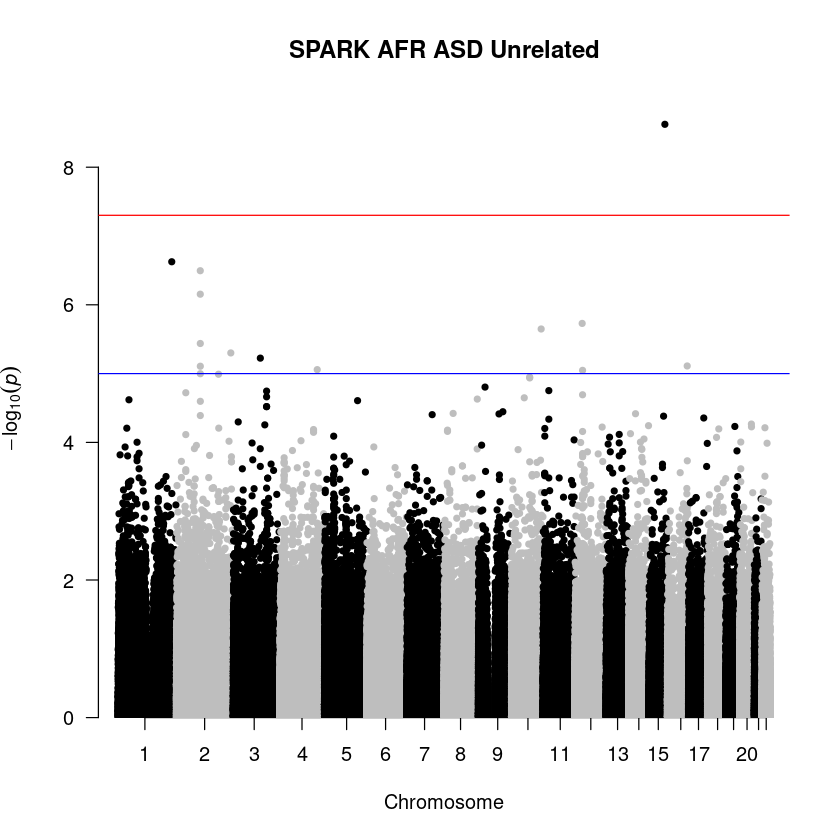

In [15]:
man_plot <- manhattan(gwas_results[!is.na(gwas_results$SNP),], 
          chr = "CHROM", 
          bp = "POS", 
          snp = "SNP", 
          p = "P", 
          col = c("black", "grey"), 
          main = "SPARK AFR ASD Unrelated")

In [17]:
dim(gwas_results[!is.na(gwas_results$SNP),])

[1] 777771      8

In [18]:
dim(gwas_results[!is.na(gwas_results$SNP)&gwas_results$P<5e-8,])

[1] 1 8

In [19]:
gwas_results[!is.na(gwas_results$SNP)&gwas_results$P<5e-8,]

,CHROM,POS,A1,A2,OR,P,chrid,SNP
,<int>,<int>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>
6847278,15,91573286,G,A,5213.89,2.37975e-09,15:91573286:A:G,rs4273013


In [64]:
rm(gwas_results, gwas_final)

In [19]:
ace_snps <- read.table("/u/home/a/afcarrol/project-pasaniuc/Projects/20240117_hg19_rsids/var_ace_merged_hg19_afr.snplist")

In [5]:
head(ace_snps)

,V1
,<chr>
1,chr1:10930:G:A
2,chr1:10989:G:A
3,chr1:51955:G:C
4,chr1:51973:GACGACGTTGTGTTGAA:G
5,chr1:52987:T:A
6,chr1:55601:T:C


In [6]:
dim(ace_snps)

[1] 54951548        1

In [10]:
head(one_kg)

,CHR,SNP,BP,A1,A2,FRQ_AFR,FRQ_AMR,FRQ_EAS,FRQ_EUR,FRQ_SAS,FLP_AFR,FLP_AMR,FLP_EAS,FLP_EUR,FLP_SAS,chrid
,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<chr>
1,1,rs2185539,566875,T,C,0.12480,0.00000,0.0000,0.00000,0.0000,1,0,0,0,0,1:566875:C:T
2,1,rs6681105,592075,C,T,0.02194,0.00000,0.0000,0.00000,0.0000,1,0,0,0,0,1:592075:T:C
3,1,rs3131972,752721,A,G,0.70950,0.26370,0.2341,0.16100,0.2219,-1,1,1,1,1,1:752721:G:A
4,1,rs3131969,754182,A,G,0.64750,0.24350,0.2669,0.12820,0.1912,-1,1,1,1,1,1:754182:G:A
5,1,rs1048488,760912,C,T,0.55520,0.19450,0.1161,0.16000,0.1892,-1,1,1,1,1,1:760912:T:C
6,1,rs12562034,768448,A,G,0.08548,0.08934,0.3958,0.09245,0.3006,1,1,1,1,1,1:768448:G:A


In [20]:
one_kg$chrid_chr <- paste0("chr", one_kg$chrid)

In [12]:
head(one_kg)

,CHR,SNP,BP,A1,A2,FRQ_AFR,FRQ_AMR,FRQ_EAS,FRQ_EUR,FRQ_SAS,FLP_AFR,FLP_AMR,FLP_EAS,FLP_EUR,FLP_SAS,chrid,chrid_chr
,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>
1,1,rs2185539,566875,T,C,0.12480,0.00000,0.0000,0.00000,0.0000,1,0,0,0,0,1:566875:C:T,chr1:566875:C:T
2,1,rs6681105,592075,C,T,0.02194,0.00000,0.0000,0.00000,0.0000,1,0,0,0,0,1:592075:T:C,chr1:592075:T:C
3,1,rs3131972,752721,A,G,0.70950,0.26370,0.2341,0.16100,0.2219,-1,1,1,1,1,1:752721:G:A,chr1:752721:G:A
4,1,rs3131969,754182,A,G,0.64750,0.24350,0.2669,0.12820,0.1912,-1,1,1,1,1,1:754182:G:A,chr1:754182:G:A
5,1,rs1048488,760912,C,T,0.55520,0.19450,0.1161,0.16000,0.1892,-1,1,1,1,1,1:760912:T:C,chr1:760912:T:C
6,1,rs12562034,768448,A,G,0.08548,0.08934,0.3958,0.09245,0.3006,1,1,1,1,1,1:768448:G:A,chr1:768448:G:A


In [21]:
sum(one_kg$chrid_chr %in% ace_snps$V1)

[1] 12511

In [15]:
head((one_kg$chrid_chr %in% ace_snps$V1))

[1] FALSE FALSE FALSE FALSE FALSE FALSE

In [21]:
one_kg$chrid2 <- paste(one_kg$CHR, one_kg$BP, one_kg$A1, one_kg$A2, sep=":")

In [22]:
one_kg$chrid2_chr <- paste0("chr", one_kg$chrid2)

In [23]:
head(one_kg)

,CHR,SNP,BP,A1,A2,FRQ_AFR,FRQ_AMR,FRQ_EAS,FRQ_EUR,FRQ_SAS,FLP_AFR,FLP_AMR,FLP_EAS,FLP_EUR,FLP_SAS,chrid,chrid_chr,chrid2,chrid2_chr
,<int>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
1,1,rs2185539,566875,T,C,0.12480,0.00000,0.0000,0.00000,0.0000,1,0,0,0,0,1:566875:C:T,chr1:566875:C:T,1:566875:T:C,chr1:566875:T:C
2,1,rs6681105,592075,C,T,0.02194,0.00000,0.0000,0.00000,0.0000,1,0,0,0,0,1:592075:T:C,chr1:592075:T:C,1:592075:C:T,chr1:592075:C:T
3,1,rs3131972,752721,A,G,0.70950,0.26370,0.2341,0.16100,0.2219,-1,1,1,1,1,1:752721:G:A,chr1:752721:G:A,1:752721:A:G,chr1:752721:A:G
4,1,rs3131969,754182,A,G,0.64750,0.24350,0.2669,0.12820,0.1912,-1,1,1,1,1,1:754182:G:A,chr1:754182:G:A,1:754182:A:G,chr1:754182:A:G
5,1,rs1048488,760912,C,T,0.55520,0.19450,0.1161,0.16000,0.1892,-1,1,1,1,1,1:760912:T:C,chr1:760912:T:C,1:760912:C:T,chr1:760912:C:T
6,1,rs12562034,768448,A,G,0.08548,0.08934,0.3958,0.09245,0.3006,1,1,1,1,1,1:768448:G:A,chr1:768448:G:A,1:768448:A:G,chr1:768448:A:G


In [24]:
sum(one_kg$chrid2_chr %in% ace_snps$V1)

[1] 6662

In [22]:
ace_1kg <- one_kg[one_kg$chrid_chr %in% ace_snps$V1, c("chrid_chr", "SNP")]

In [23]:
head(ace_1kg)

,chrid_chr,SNP
,<chr>,<chr>
109,chr1:1113121:G:A,rs12092254
214,chr1:1366830:G:A,rs873927
311,chr1:1759026:C:T,rs9786963
393,chr1:2004098:G:A,rs6663158
917,chr1:3252007:C:T,rs4648478
1051,chr1:3497109:G:A,rs2821050


In [25]:
dim(ace_1kg)

[1] 12511     2

In [26]:
write.csv(ace_1kg, "ace_rsids.csv")

In [14]:
ace_1kg <- read_csv("ace_rsids.csv")

New names:
• `` -> `...1`
Rows: 12511 Columns: 3
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): chrid_chr, SNP
dbl (1): ...1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
head(ace_1kg)

...1,chrid_chr,SNP
<dbl>,<chr>,<chr>
109,chr1:1113121:G:A,rs12092254
214,chr1:1366830:G:A,rs873927
311,chr1:1759026:C:T,rs9786963
393,chr1:2004098:G:A,rs6663158
917,chr1:3252007:C:T,rs4648478
1051,chr1:3497109:G:A,rs2821050


In [7]:
getwd()

[1] "/u/project/pasaniuc/afcarrol/Projects/20240117_hg19_rsids"

In [8]:
# List of SNPs to filter
snp_list <- ace_1kg$chrid_chr

# Path for the output SNP list file
output_path <- "/u/project/pasaniuc/afcarrol/Projects/20240117_hg19_rsids/ace_1kg_snps.txt"

# Write SNP IDs to the file
writeLines(as.character(snp_list), con = output_path)


In [15]:
# SNP names to change to RSIDs
ace_1kg <- ace_1kg[,c("chrid_chr","SNP")]

# Path for the output SNP name update file
output_path <- "/u/project/pasaniuc/afcarrol/Projects/20240117_hg19_rsids/new_snp_names.txt"

# Write the data frame to the file
write.table(ace_1kg, file = output_path, sep = "\t", quote = FALSE, row.names = FALSE, col.names = FALSE)


In [16]:
dim(ace_1kg)

[1] 12511     2